In [ ]:
pip install FER

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.9 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of opencv-contrib-python to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 25.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 70.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 87.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.1/69.1 MB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 102.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 755.5/755.5 MB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 98.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 85.0 MB/s eta 0:00:00
   ━━━━━━━━━━

In [ ]:
import cv2
import os

video_path = '/content/videoplayback.mp4'
output_dir = '/content/frames'
os.makedirs(output_dir, exist_ok=True)

cap = cv2.VideoCapture(video_path)
fps = cap.get(cv2.CAP_PROP_FPS)
frame_interval = int(fps * 10)  # every 10 seconds

frame_count = 0
saved_count = 0

while True:
    ret, frame = cap.read()
    if not ret:
        break
    if frame_count % frame_interval == 0:
        cv2.imwrite(os.path.join(output_dir, f'frame_{saved_count:05d}.jpg'), frame)
        saved_count += 1
    frame_count += 1

cap.release()
print(f"Total frames saved: {saved_count}")

Total frames saved: 1094


In [ ]:
pip install face_recognition

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.1/100.1 MB 4.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for face-recognition-models: filename=face_recognition_models-0.3.0-py2.py3-none-any.whl size=100566166 sha256=c69809b5bc78611995a12ab38c3bed8032e50045d65de20ab5d3750fded1c9ee
  Stored in directory: /root/.cache/pip/wheels/8f/47/c8/f44c5aebb7507f7c8a2c0bd23151d732d0f0bd6884ad4ac635
Successfully built face-recognition-models


In [ ]:
import cv2
import glob
import os

frame_files = glob.glob('/content/frames/*.jpg')
faces_dir = '/content/faces'
os.makedirs(faces_dir, exist_ok=True)

# Load the pre-trained Haar Cascade classifier for face detection
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

for f in frame_files:
    # Read the image in grayscale for face detection
    image = cv2.imread(f)
    gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Detect faces in the image
    # The detectMultiScale function detects objects of different sizes in the input image.
    # The detected objects are returned as a list of rectangles.
    face_locations = face_cascade.detectMultiScale(gray_image, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30))

    for i, (x, y, w, h) in enumerate(face_locations):
        # Extract the face region
        face = image[y:y+h, x:x+w]
        # Save the extracted face
        cv2.imwrite(os.path.join(faces_dir, f'{os.path.basename(f)[:-4]}_face_{i}.jpg'), face)

print(f"Finished extracting faces from {len(frame_files)} frames.")

Finished extracting faces from 1094 frames.


In [ ]:
from fer import FER
import glob
import pandas as pd
import os

face_files = glob.glob('/content/faces/*.jpg')
emotion_detector = FER(mtcnn=True)
emotions_list = []

for face_file in face_files:
    try:
        image = cv2.imread(face_file)
        # Analyze emotions in the face
        result = emotion_detector.detect_emotions(image)

        if result:
            # Assuming only one face per image file (which is true based on our extraction)
            emotions = result[0]['emotions']
            emotions['filename'] = os.path.basename(face_file)
            emotions_list.append(emotions)
        else:
            # Handle cases where no face is detected in the file (shouldn't happen with our extraction)
            print(f"No face detected in {face_file}")

    except Exception as e:
        print(f"Error processing {face_file}: {e}")

# Convert the list of emotion dictionaries to a pandas DataFrame
emotions_df = pd.DataFrame(emotions_list)

# Display the first few rows of the DataFrame
display(emotions_df.head())

# Save the DataFrame to a CSV file
emotions_df.to_csv('/content/face_emotions.csv', index=False)

print("Emotion analysis complete. Results saved to /content/face_emotions.csv")

/usr/local/lib/python3.12/dist-packages/moviepy/config_defaults.py:47: SyntaxWarning: invalid escape sequence '\P'
  IMAGEMAGICK_BINARY = r"C:\Program Files\ImageMagick-6.8.8-Q16\magick.exe"
/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:294: SyntaxWarning: invalid escape sequence '\d'
  lines_video = [l for l in lines if ' Video: ' in l and re.search('\d+x\d+', l)]
/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:367: SyntaxWarning: invalid escape sequence '\d'
  rotation_lines = [l for l in lines if 'rotate          :' in l and re.search('\d+$', l)]
/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:370: SyntaxWarning: invalid escape sequence '\d'
  match = re.search('\d+$', rotation_line)
  if event.key is 'enter':

Expected: ['input_1']
Received: inputs=Tensor(shape=(1, 64, 64))
  warnings.warn(msg)



No face detected in /content/faces/frame_00621_face_0.jpg
No face detected in /content/faces/frame_00506_face_0.jpg
No face detected in /content/faces/frame_00607_face_0.jpg
No face detected in /content/faces/frame_00106_face_0.jpg
No face detected in /content/faces/frame_00624_face_0.jpg
No face detected in /content/faces/frame_00276_face_0.jpg
No face detected in /content/faces/frame_00970_face_0.jpg
No face detected in /content/faces/frame_00379_face_0.jpg
No face detected in /content/faces/frame_00768_face_1.jpg
No face detected in /content/faces/frame_00915_face_0.jpg
No face detected in /content/faces/frame_00060_face_1.jpg
No face detected in /content/faces/frame_00803_face_0.jpg
No face detected in /content/faces/frame_00799_face_0.jpg
No face detected in /content/faces/frame_00614_face_0.jpg
No face detected in /content/faces/frame_00906_face_0.jpg
No face detected in /content/faces/frame_00567_face_2.jpg
No face detected in /content/faces/frame_00353_face_0.jpg
No face detect

Expected: ['input_1']
Received: inputs=Tensor(shape=(2, 64, 64))
  warnings.warn(msg)



No face detected in /content/faces/frame_00710_face_0.jpg
No face detected in /content/faces/frame_00965_face_0.jpg
No face detected in /content/faces/frame_00753_face_1.jpg
No face detected in /content/faces/frame_00702_face_0.jpg
No face detected in /content/faces/frame_00678_face_0.jpg
No face detected in /content/faces/frame_00399_face_0.jpg
No face detected in /content/faces/frame_00607_face_1.jpg
No face detected in /content/faces/frame_00747_face_0.jpg
No face detected in /content/faces/frame_00838_face_0.jpg
No face detected in /content/faces/frame_00875_face_2.jpg
No face detected in /content/faces/frame_00052_face_1.jpg
No face detected in /content/faces/frame_00038_face_0.jpg
No face detected in /content/faces/frame_00977_face_0.jpg
No face detected in /content/faces/frame_00683_face_0.jpg
No face detected in /content/faces/frame_01088_face_0.jpg
No face detected in /content/faces/frame_00922_face_0.jpg
No face detected in /content/faces/frame_00745_face_0.jpg
No face detect

,angry,disgust,fear,happy,sad,surprise,neutral,filename
0,0.58,0.01,0.21,0.03,0.13,0.01,0.04,frame_00591_face_0.jpg
1,0.63,0.00,0.11,0.13,0.11,0.00,0.02,frame_00015_face_1.jpg
2,0.00,0.00,0.00,1.00,0.00,0.00,0.00,frame_00869_face_0.jpg
3,0.19,0.00,0.33,0.05,0.30,0.03,0.11,frame_01060_face_1.jpg
4,0.08,0.00,0.17,0.05,0.54,0.06,0.10,frame_00110_face_0.jpg


Emotion analysis complete. Results saved to /content/face_emotions.csv


In [ ]:
!pip uninstall -y face_recognition dlib
%env DLIB_USE_CUDA=0
!pip install dlib
!pip install face_recognition

env: DLIB_USE_CUDA=0
  Using cached dlib-20.0.0.tar.gz (3.3 MB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  error: subprocess-exited-with-error
  
  × Building wheel for dlib (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  ERROR: Failed building wheel for dlib
Failed to build dlib
ERROR: ERROR: Failed to build installable wheels for some pyproject.toml based projects (dlib)
  Using cached face_recognition-1.3.0-py2.py3-none-any.whl.metadata (21 kB)
  Using cached dlib-20.0.0.tar.gz (3.3 MB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Using cached face_recognition-1.3.0-py2.py3-none-any.whl (15 kB)
  error: subprocess-exited-with-error
  
  × Building wheel for dlib (pyproject

In [ ]:
!apt-get update
!apt-get install -y cmake
!apt-get install -y libgtk-3-dev
!apt-get install -y libboost-all-dev

Get:1 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:2 https://cli.github.com/packages stable InRelease [3,917 B]
Get:3 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:4 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Hit:5 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:7 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:8 http://security.ubuntu.com/ubuntu jammy-security/universe amd64 Packages [1,271 kB]
Get:9 http://security.ubuntu.com/ubuntu jammy-security/main amd64 Packages [3,253 kB]
Hit:10 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Get:11 http://security.ubuntu.com/ubuntu jammy-security/restricted amd64 Packages [5,235 kB]
Get:12 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [9,191 kB]
Get:13 http://archive.ubuntu.com/ubuntu jammy-backpo

In [ ]:
!pip uninstall -y face_recognition dlib
%env DLIB_USE_CUDA=0
!pip install dlib
!pip install face_recognition

env: DLIB_USE_CUDA=0
  Using cached dlib-20.0.0.tar.gz (3.3 MB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  error: subprocess-exited-with-error
  
  × Building wheel for dlib (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  ERROR: Failed building wheel for dlib
Failed to build dlib
ERROR: ERROR: Failed to build installable wheels for some pyproject.toml based projects (dlib)
  Using cached face_recognition-1.3.0-py2.py3-none-any.whl.metadata (21 kB)
  Using cached dlib-20.0.0.tar.gz (3.3 MB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Using cached face_recognition-1.3.0-py2.py3-none-any.whl (15 kB)
  error: subprocess-exited-with-error
  
  × Building wheel for dlib (pyproject

In [ ]:
import pandas as pd

# Load emotion CSV (already in Colab /content/)
emotion_df = pd.read_csv('/content/face_emotions.csv')
emotion_df.head()


,angry,disgust,fear,happy,sad,surprise,neutral,filename
0,0.58,0.01,0.21,0.03,0.13,0.01,0.04,frame_00591_face_0.jpg
1,0.63,0.00,0.11,0.13,0.11,0.00,0.02,frame_00015_face_1.jpg
2,0.00,0.00,0.00,1.00,0.00,0.00,0.00,frame_00869_face_0.jpg
3,0.19,0.00,0.33,0.05,0.30,0.03,0.11,frame_01060_face_1.jpg
4,0.08,0.00,0.17,0.05,0.54,0.06,0.10,frame_00110_face_0.jpg


from matplotlib import pyplot as plt
_df_0['angry'].plot(kind='hist', bins=20, title='angry')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_1['disgust'].plot(kind='hist', bins=20, title='disgust')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_2['fear'].plot(kind='hist', bins=20, title='fear')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_3['happy'].plot(kind='hist', bins=20, title='happy')
plt.gca().spines[['top', 'right',]].set_visible(False)

...

from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_14['filename'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_14, x='disgust', y='filename', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)


Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_15['filename'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_15, x='fear', y='filename', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)


Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_16['filename'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_16, x='happy', y='filename', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

In [ ]:
# Extract frame number from image filename
emotion_df['frame_number'] = emotion_df['filename'].apply(lambda x: int(x.split('_')[1]))

# Assuming each frame was extracted every 10 seconds
seconds_per_frame = 10
emotion_df['time_sec'] = emotion_df['frame_number'] * seconds_per_frame

# Optional: convert to minutes
emotion_df['time_min'] = emotion_df['time_sec'] / 60

emotion_df.head()


,angry,disgust,fear,happy,sad,surprise,neutral,filename,frame_number,time_sec,time_min
0,0.58,0.01,0.21,0.03,0.13,0.01,0.04,frame_00591_face_0.jpg,591,5910,98.500000
1,0.63,0.00,0.11,0.13,0.11,0.00,0.02,frame_00015_face_1.jpg,15,150,2.500000
2,0.00,0.00,0.00,1.00,0.00,0.00,0.00,frame_00869_face_0.jpg,869,8690,144.833333
3,0.19,0.00,0.33,0.05,0.30,0.03,0.11,frame_01060_face_1.jpg,1060,10600,176.666667
4,0.08,0.00,0.17,0.05,0.54,0.06,0.10,frame_00110_face_0.jpg,110,1100,18.333333


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.countplot(data=emotion_df, x='emotion', order=emotion_df['emotion'].value_counts().index)
plt.title("Overall Emotion Distribution")
plt.xlabel("Emotion")
plt.ylabel("Count")
plt.show()


KeyError: 'emotion'

<Figure size 800x500 with 0 Axes>

In [ ]:
import pandas as pd

# Load your CSV
df = pd.read_csv('/content/face_emotions.csv')
df.head()


,angry,disgust,fear,happy,sad,surprise,neutral,filename
0,0.58,0.01,0.21,0.03,0.13,0.01,0.04,frame_00591_face_0.jpg
1,0.63,0.00,0.11,0.13,0.11,0.00,0.02,frame_00015_face_1.jpg
2,0.00,0.00,0.00,1.00,0.00,0.00,0.00,frame_00869_face_0.jpg
3,0.19,0.00,0.33,0.05,0.30,0.03,0.11,frame_01060_face_1.jpg
4,0.08,0.00,0.17,0.05,0.54,0.06,0.10,frame_00110_face_0.jpg


In [ ]:
# Find the emotion with the highest score for each frame
emotion_cols = ['angry','disgust','fear','happy','sad','surprise','neutral']

df['dominant_emotion'] = df[emotion_cols].idxmax(axis=1)
df.head()


,angry,disgust,fear,happy,sad,surprise,neutral,filename,dominant_emotion
0,0.58,0.01,0.21,0.03,0.13,0.01,0.04,frame_00591_face_0.jpg,angry
1,0.63,0.00,0.11,0.13,0.11,0.00,0.02,frame_00015_face_1.jpg,angry
2,0.00,0.00,0.00,1.00,0.00,0.00,0.00,frame_00869_face_0.jpg,happy
3,0.19,0.00,0.33,0.05,0.30,0.03,0.11,frame_01060_face_1.jpg,fear
4,0.08,0.00,0.17,0.05,0.54,0.06,0.10,frame_00110_face_0.jpg,sad


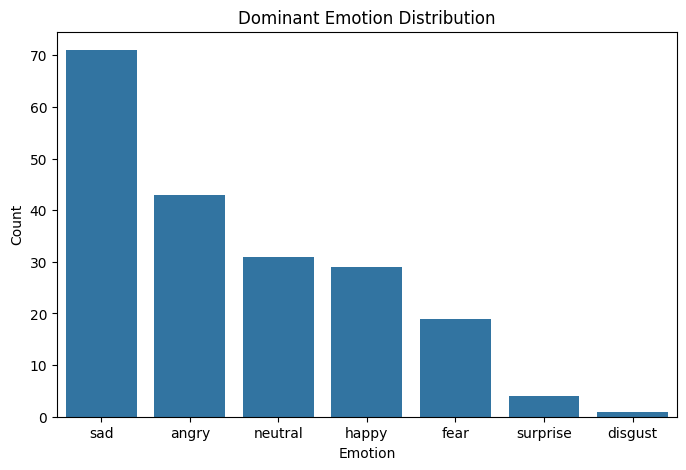

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.countplot(data=df, x='dominant_emotion', order=df['dominant_emotion'].value_counts().index)
plt.title("Dominant Emotion Distribution")
plt.xlabel("Emotion")
plt.ylabel("Count")
plt.show()


In [ ]:
df['high_pressure'] = df['dominant_emotion'].apply(lambda x: 1 if x in ['angry','sad'] else 0)

# Count high-pressure frames
high_pressure_count = df['high_pressure'].sum()
print(f"Total high-pressure frames: {high_pressure_count}")


Total high-pressure frames: 114


Total high-pressure frames: 114


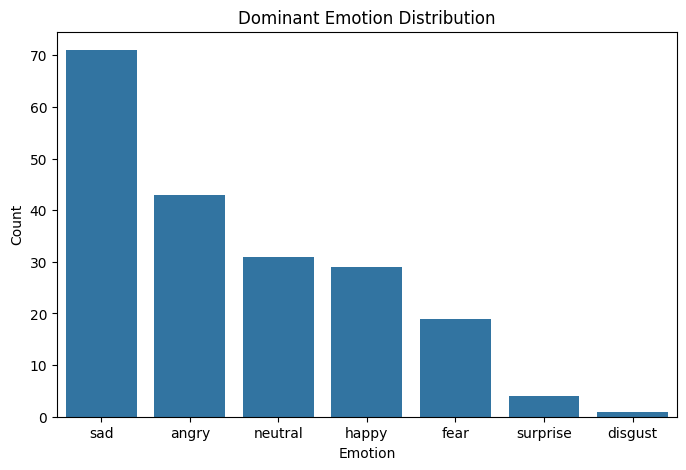

In [ ]:
# Mark high-pressure frames
df['high_pressure'] = df['dominant_emotion'].apply(lambda x: 1 if x in ['angry','sad'] else 0)

# Total high-pressure frames
total_hp = df['high_pressure'].sum()
print(f"Total high-pressure frames: {total_hp}")

# Visualize
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.countplot(data=df, x='dominant_emotion', order=df['dominant_emotion'].value_counts().index)
plt.title("Dominant Emotion Distribution")
plt.xlabel("Emotion")
plt.ylabel("Count")
plt.show()


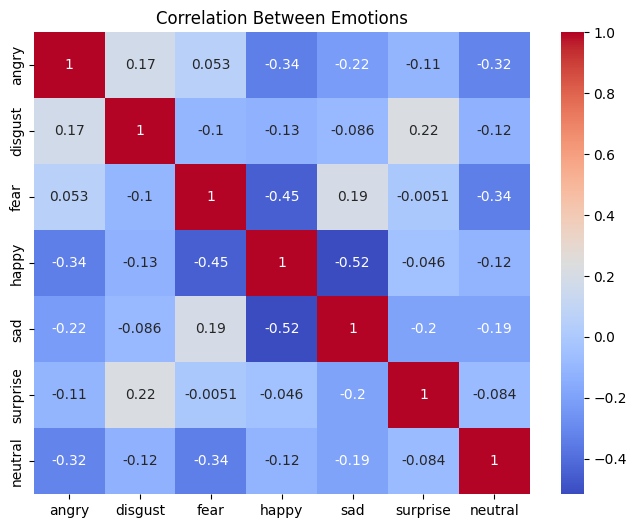

In [ ]:
# Compute correlation matrix
corr_matrix = df[emotion_cols].corr()

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Between Emotions")
plt.show()


In [ ]:
df['high_pressure'] = df['dominant_emotion'].apply(lambda x: 1 if x in ['angry','sad'] else 0)

# Correlation between high-pressure frames and other emotions
hp_corr = df[emotion_cols + ['high_pressure']].corr()['high_pressure'].sort_values(ascending=False)
print("Correlation with High-Pressure Frames:")
print(hp_corr)


Correlation with High-Pressure Frames:
high_pressure    1.000000
sad              0.586350
angry            0.409631
disgust          0.066663
fear             0.029629
surprise        -0.173544
neutral         -0.379207
happy           -0.457992
Name: high_pressure, dtype: float64


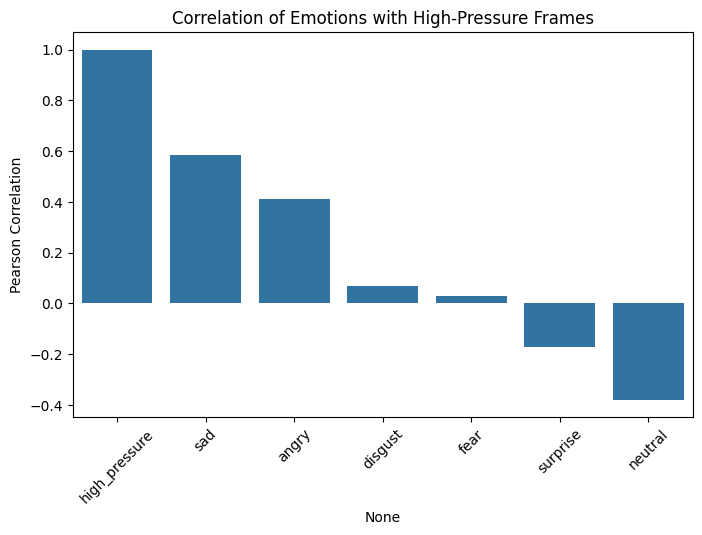

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(x=hp_corr.index[:-1], y=hp_corr.values[:-1])
plt.title("Correlation of Emotions with High-Pressure Frames")
plt.ylabel("Pearson Correlation")
plt.xticks(rotation=45)
plt.show()


In [ ]:
import pandas as pd

# Load CSV
df = pd.read_csv('/content/face_emotions.csv')

# Emotion columns
emotion_cols = ['angry','disgust','fear','happy','sad','surprise','neutral']

# Determine dominant emotion
df['dominant_emotion'] = df[emotion_cols].idxmax(axis=1)

# Define performance weights
# Positive emotions → +1, Negative/high-pressure → -1
performance_weights = {
    'happy': 1,
    'neutral': 1,
    'surprise': 1,
    'angry': -1,
    'sad': -1,
    'fear': -1,
    'disgust': -1
}

df['performance_score'] = df['dominant_emotion'].map(performance_weights)

df.head()


,angry,disgust,fear,happy,sad,surprise,neutral,filename,dominant_emotion,performance_score
0,0.58,0.01,0.21,0.03,0.13,0.01,0.04,frame_00591_face_0.jpg,angry,-1
1,0.63,0.00,0.11,0.13,0.11,0.00,0.02,frame_00015_face_1.jpg,angry,-1
2,0.00,0.00,0.00,1.00,0.00,0.00,0.00,frame_00869_face_0.jpg,happy,1
3,0.19,0.00,0.33,0.05,0.30,0.03,0.11,frame_01060_face_1.jpg,fear,-1
4,0.08,0.00,0.17,0.05,0.54,0.06,0.10,frame_00110_face_0.jpg,sad,-1


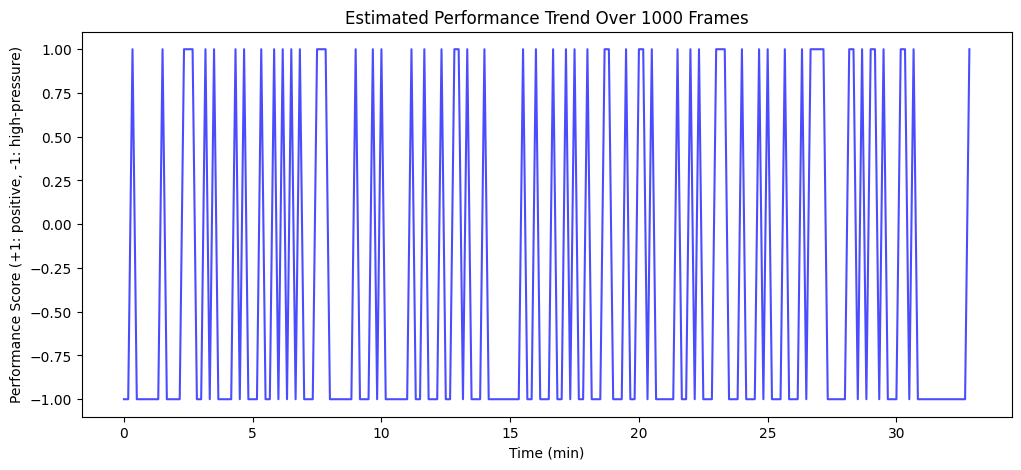

In [ ]:
import matplotlib.pyplot as plt

# Approximate time per frame
seconds_per_frame = 10
df['time_sec'] = df.index * seconds_per_frame
df['time_min'] = df['time_sec'] / 60

# Plot performance over time
plt.figure(figsize=(12,5))
plt.plot(df['time_min'], df['performance_score'], color='blue', alpha=0.7)
plt.title("Estimated Performance Trend Over 1000 Frames")
plt.xlabel("Time (min)")
plt.ylabel("Performance Score (+1: positive, -1: high-pressure)")
plt.show()


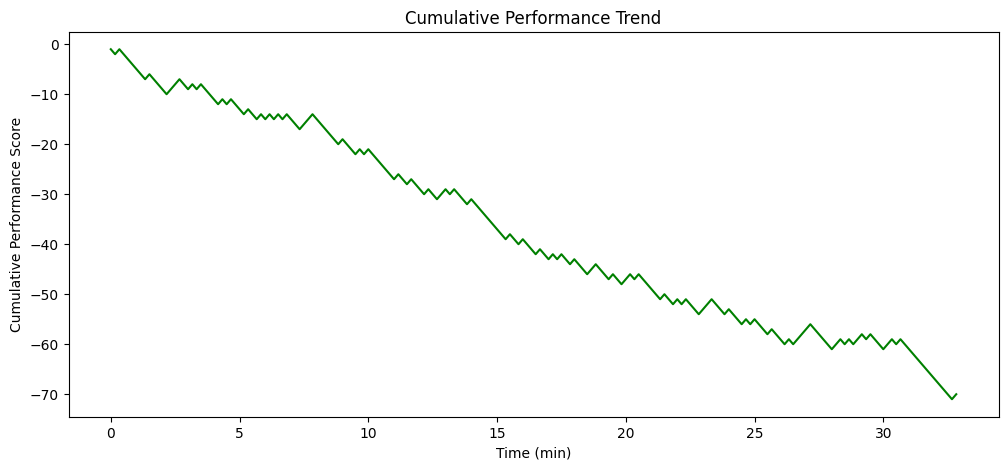

In [ ]:
# Cumulative performance
df['cumulative_perf'] = df['performance_score'].cumsum()

plt.figure(figsize=(12,5))
plt.plot(df['time_min'], df['cumulative_perf'], color='green')
plt.title("Cumulative Performance Trend")
plt.xlabel("Time (min)")
plt.ylabel("Cumulative Performance Score")
plt.show()


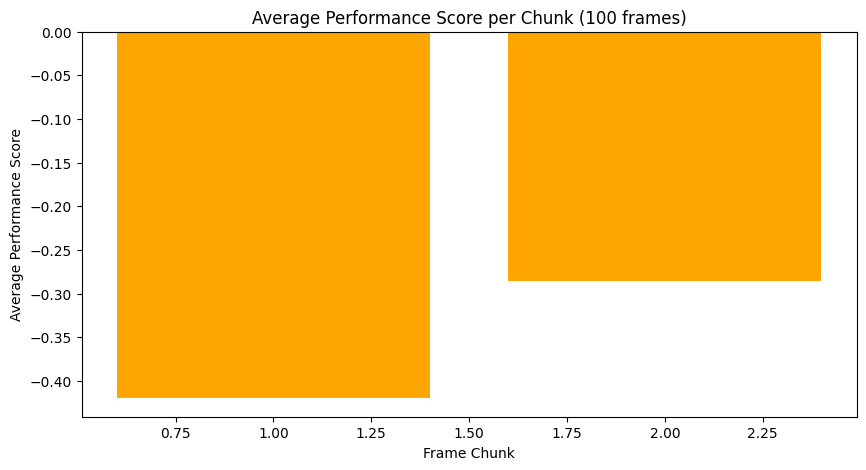

In [ ]:
# Count high-pressure frames in chunks (e.g., every 100 frames)
chunk_size = 100
df['chunk'] = (df.index // chunk_size) + 1
chunk_perf = df.groupby('chunk')['performance_score'].mean().reset_index()

plt.figure(figsize=(10,5))
plt.bar(chunk_perf['chunk'], chunk_perf['performance_score'], color='orange')
plt.title("Average Performance Score per Chunk (100 frames)")
plt.xlabel("Frame Chunk")
plt.ylabel("Average Performance Score")
plt.show()


In [ ]:
import pandas as pd

# Load CSV
df = pd.read_csv('/content/face_emotions.csv')

# Emotion columns
emotion_cols = ['angry','disgust','fear','happy','sad','surprise','neutral']

# Approximate time per frame
seconds_per_frame = 10
df['time_min'] = df.index * seconds_per_frame / 60

df.head()


,angry,disgust,fear,happy,sad,surprise,neutral,filename,time_min
0,0.58,0.01,0.21,0.03,0.13,0.01,0.04,frame_00591_face_0.jpg,0.000000
1,0.63,0.00,0.11,0.13,0.11,0.00,0.02,frame_00015_face_1.jpg,0.166667
2,0.00,0.00,0.00,1.00,0.00,0.00,0.00,frame_00869_face_0.jpg,0.333333
3,0.19,0.00,0.33,0.05,0.30,0.03,0.11,frame_01060_face_1.jpg,0.500000
4,0.08,0.00,0.17,0.05,0.54,0.06,0.10,frame_00110_face_0.jpg,0.666667


In [ ]:
# Assign weights: positive emotions = +1, high-pressure = -1
performance_weights = {
    'happy': 1,
    'neutral': 1,
    'surprise': 1,
    'angry': -1,
    'sad': -1,
    'fear': -1,
    'disgust': -1
}


In [ ]:
# Multiply each emotion probability by its weight
df['performance_score'] = df[emotion_cols].apply(lambda row: sum(row[emo]*performance_weights[emo] for emo in emotion_cols), axis=1)

# Normalize score to [-1,1] if desired
max_abs = df['performance_score'].abs().max()
df['performance_score_normalized'] = df['performance_score'] / max_abs


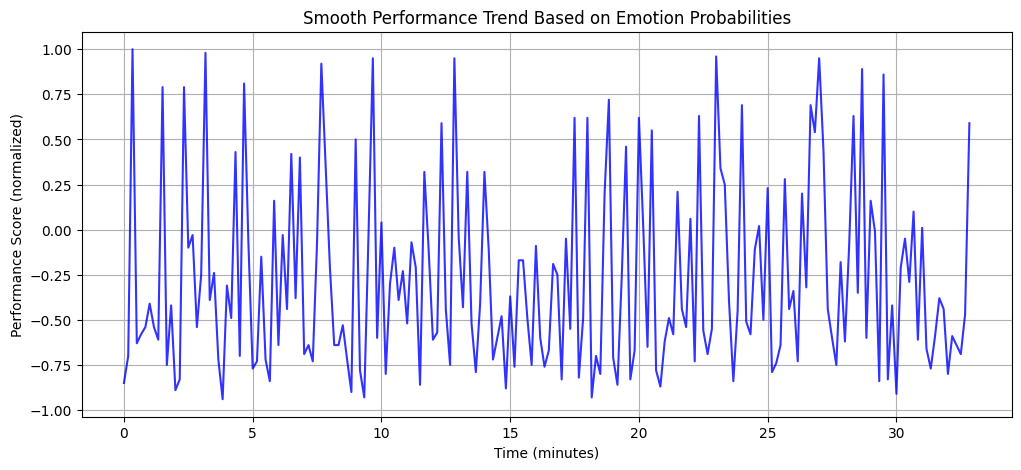

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(df['time_min'], df['performance_score_normalized'], color='blue', alpha=0.8)
plt.title("Smooth Performance Trend Based on Emotion Probabilities")
plt.xlabel("Time (minutes)")
plt.ylabel("Performance Score (normalized)")
plt.grid(True)
plt.show()


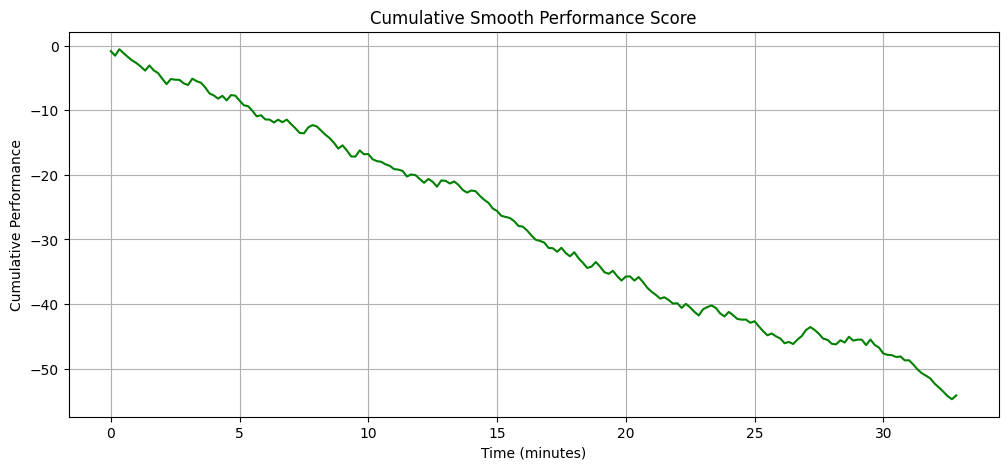

In [ ]:
df['cumulative_perf'] = df['performance_score_normalized'].cumsum()

plt.figure(figsize=(12,5))
plt.plot(df['time_min'], df['cumulative_perf'], color='green')
plt.title("Cumulative Smooth Performance Score")
plt.xlabel("Time (minutes)")
plt.ylabel("Cumulative Performance")
plt.grid(True)
plt.show()


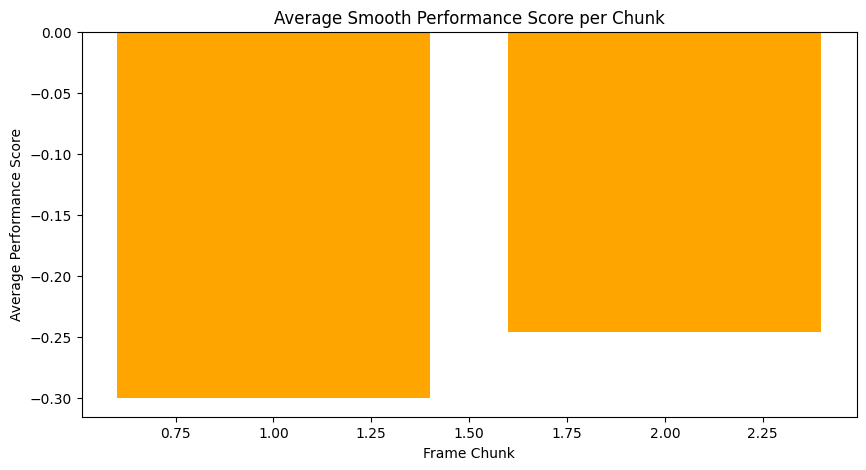

In [ ]:
chunk_size = 100  # 100 frames per chunk
df['chunk'] = (df.index // chunk_size) + 1
chunk_perf = df.groupby('chunk')['performance_score_normalized'].mean().reset_index()

plt.figure(figsize=(10,5))
plt.bar(chunk_perf['chunk'], chunk_perf['performance_score_normalized'], color='orange')
plt.title("Average Smooth Performance Score per Chunk")
plt.xlabel("Frame Chunk")
plt.ylabel("Average Performance Score")
plt.show()


In [ ]:
import pandas as pd

# Load CSV
df = pd.read_csv('/content/face_emotions.csv')

# Emotion columns
emotion_cols = ['angry','disgust','fear','happy','sad','surprise','neutral']

# Approximate time per frame
seconds_per_frame = 10
df['time_min'] = df.index * seconds_per_frame / 60

# Define weights
weights = {
    'happy': 1,
    'neutral': 1,
    'surprise': 1,
    'angry': -1,
    'sad': -1,
    'fear': -1,
    'disgust': -1
}

# Smooth performance score
df['performance_score'] = df[emotion_cols].apply(lambda row: sum(row[emo]*weights[emo] for emo in emotion_cols), axis=1)

# High-pressure score (sum of negative emotions only)
df['pressure_score'] = df[['angry','sad','fear','disgust']].sum(axis=1)


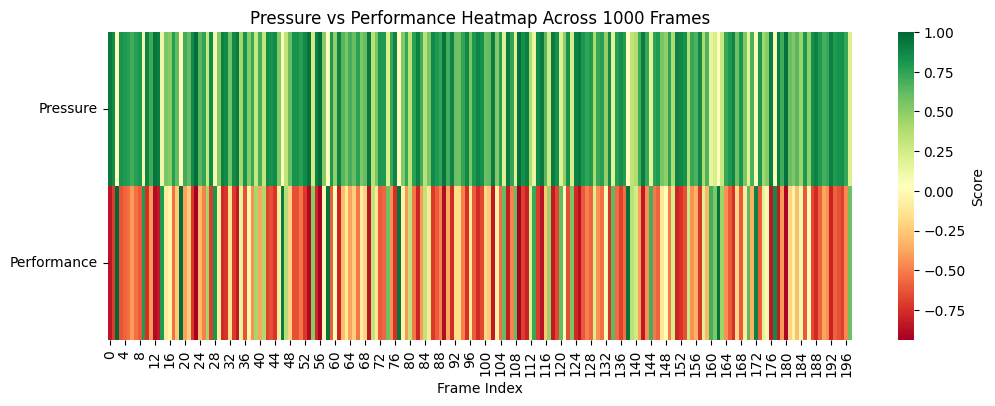

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a 2-row matrix: row 0 = pressure, row 1 = performance
heatmap_data = df[['pressure_score','performance_score']].transpose()

plt.figure(figsize=(12,4))
sns.heatmap(heatmap_data, cmap='RdYlGn', cbar_kws={'label':'Score'})
plt.yticks([0.5,1.5], ['Pressure','Performance'], rotation=0)
plt.title("Pressure vs Performance Heatmap Across 1000 Frames")
plt.xlabel("Frame Index")
plt.show()


In [ ]:
import numpy as np

frames_per_ball = 5
num_balls = len(df_emotions) // frames_per_ball

ball_data = []

for i in range(num_balls):
    ball_frames = df_emotions.iloc[i*frames_per_ball : (i+1)*frames_per_ball]
    avg_emotions = ball_frames[emotion_cols].mean()
    dominant_emotion = avg_emotions.idxmax()
    performance_score = sum(avg_emotions[emo]*weights[emo] for emo in emotion_cols)
    perform_under_pressure = int(performance_score > 0)

    ball_data.append({
        'ball_number': i+1,
        **avg_emotions.to_dict(),
        'dominant_emotion': dominant_emotion,
        'performance_score': performance_score,
        'perform_under_pressure': perform_under_pressure
    })

df_ball = pd.DataFrame(ball_data)


In [ ]:
df_ball.to_csv('ball_by_ball_emotions.csv', index=False)


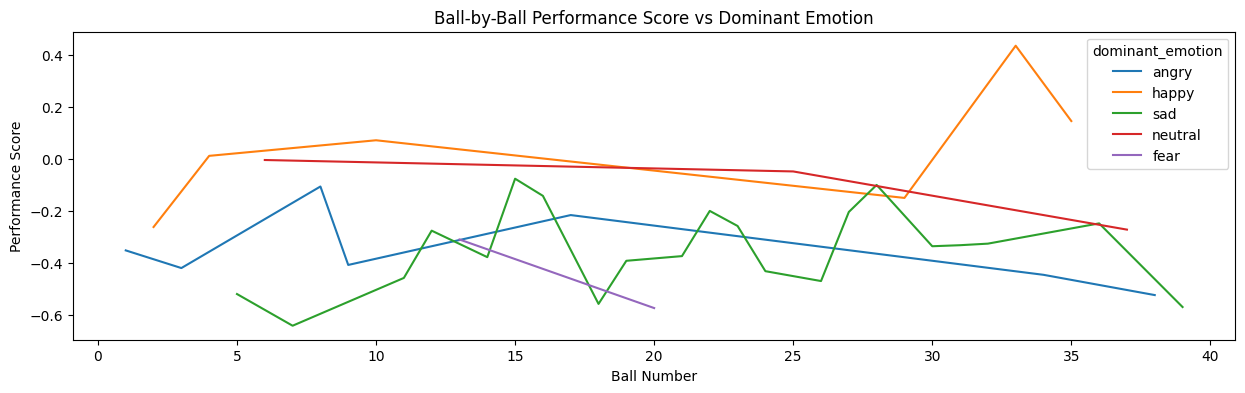

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15,4))
sns.lineplot(data=df_ball, x='ball_number', y='performance_score', hue='dominant_emotion', palette='tab10')
plt.title("Ball-by-Ball Performance Score vs Dominant Emotion")
plt.xlabel("Ball Number")
plt.ylabel("Performance Score")
plt.show()


In [ ]:
!pip install pandas matplotlib seaborn scikit-learn --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix


In [ ]:
df_emotions = pd.read_csv('/content/face_emotions.csv')

# Check columns
print(df_emotions.head())
emotion_cols = ['angry','disgust','fear','happy','sad','surprise','neutral']


   angry  disgust  fear  happy   sad  surprise  neutral  \
0   0.58     0.01  0.21   0.03  0.13      0.01     0.04   
1   0.63     0.00  0.11   0.13  0.11      0.00     0.02   
2   0.00     0.00  0.00   1.00  0.00      0.00     0.00   
3   0.19     0.00  0.33   0.05  0.30      0.03     0.11   
4   0.08     0.00  0.17   0.05  0.54      0.06     0.10   

                 filename  
0  frame_00591_face_0.jpg  
1  frame_00015_face_1.jpg  
2  frame_00869_face_0.jpg  
3  frame_01060_face_1.jpg  
4  frame_00110_face_0.jpg  


In [ ]:
weights = {
    'happy': 1, 'neutral': 1, 'surprise': 1,
    'angry': -1, 'sad': -1, 'fear': -1, 'disgust': -1
}

df_emotions['performance_score'] = df_emotions[emotion_cols].apply(
    lambda row: sum(row[emo]*weights[emo] for emo in emotion_cols), axis=1
)

# High-pressure label: 1 = performing well, 0 = stressed
df_emotions['perform_under_pressure'] = (df_emotions['performance_score'] > 0).astype(int)

# Dominant emotion per frame
df_emotions['dominant_emotion'] = df_emotions[emotion_cols].idxmax(axis=1)


In [ ]:
frames_per_ball = 5  # adjust depending on frame density
num_balls = len(df_emotions) // frames_per_ball
ball_data = []

for i in range(num_balls):
    ball_frames = df_emotions.iloc[i*frames_per_ball : (i+1)*frames_per_ball]
    avg_emotions = ball_frames[emotion_cols].mean()
    dominant_emotion = avg_emotions.idxmax()
    performance_score = sum(avg_emotions[emo]*weights[emo] for emo in emotion_cols)
    perform_under_pressure = int(performance_score > 0)

    ball_data.append({
        'ball_number': i+1,
        **avg_emotions.to_dict(),
        'dominant_emotion': dominant_emotion,
        'performance_score': performance_score,
        'perform_under_pressure': perform_under_pressure
    })

df_ball = pd.DataFrame(ball_data)
df_ball.head()


,ball_number,angry,disgust,fear,happy,sad,surprise,neutral,dominant_emotion,performance_score,perform_under_pressure
0,1,0.296,0.002,0.164,0.252,0.216,0.020,0.054,angry,-0.352,0
1,2,0.246,0.024,0.144,0.250,0.216,0.040,0.078,happy,-0.262,0
2,3,0.330,0.016,0.122,0.180,0.242,0.046,0.064,angry,-0.420,0
3,4,0.190,0.028,0.122,0.278,0.152,0.020,0.206,happy,0.012,1
4,5,0.174,0.010,0.244,0.038,0.332,0.056,0.146,sad,-0.520,0


In [ ]:
X = df_ball[emotion_cols]
y = df_ball['perform_under_pressure']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


  warnings.warn(



Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         8

    accuracy                           1.00         8
   macro avg       1.00      1.00      1.00         8
weighted avg       1.00      1.00      1.00         8

Confusion Matrix:
 [[8]]


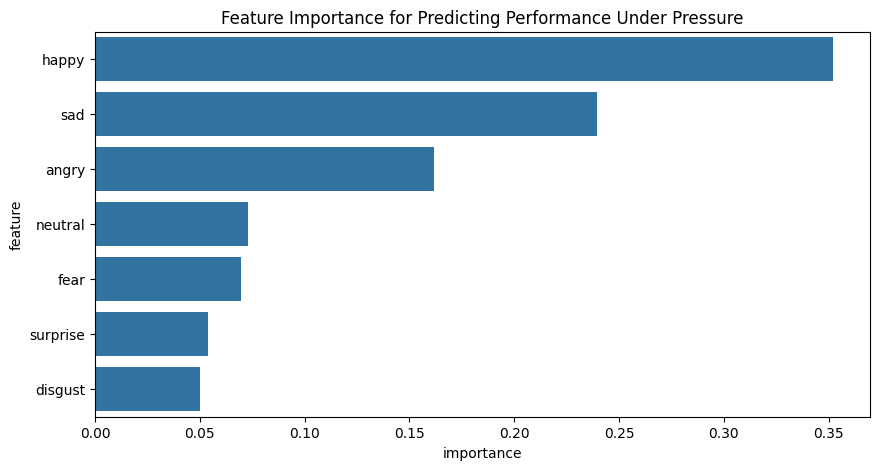

In [ ]:
feat_importance = pd.DataFrame({
    'feature': emotion_cols,
    'importance': clf.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10,5))
sns.barplot(x='importance', y='feature', data=feat_importance)
plt.title("Feature Importance for Predicting Performance Under Pressure")
plt.show()


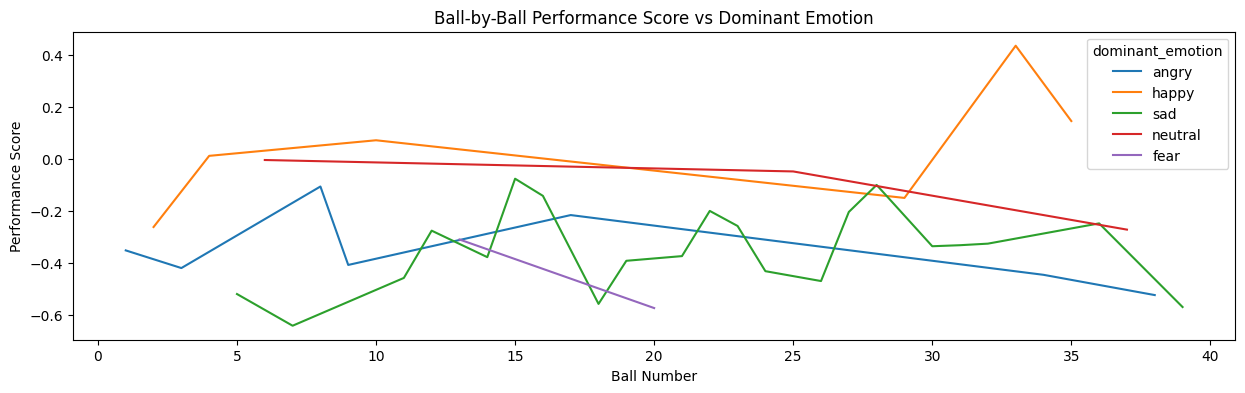

In [ ]:
plt.figure(figsize=(15,4))
sns.lineplot(data=df_ball, x='ball_number', y='performance_score', hue='dominant_emotion', palette='tab10')
plt.title("Ball-by-Ball Performance Score vs Dominant Emotion")
plt.xlabel("Ball Number")
plt.ylabel("Performance Score")
plt.show()


In [ ]:
from sklearn.model_selection import cross_val_score, StratifiedKFold


In [ ]:
clf = RandomForestClassifier(n_estimators=100, random_state=42)


In [ ]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)  # 5-fold CV


In [ ]:
scores = cross_val_score(clf, X, y, cv=skf, scoring='accuracy')
print("Cross-Validation Accuracy Scores:", scores)
print("Mean Accuracy:", scores.mean())
print("Standard Deviation:", scores.std())


  warnings.warn(



Cross-Validation Accuracy Scores: [0.875 1.    1.    0.875 1.   ]
Mean Accuracy: 0.95
Standard Deviation: 0.06123724356957946


  warnings.warn(



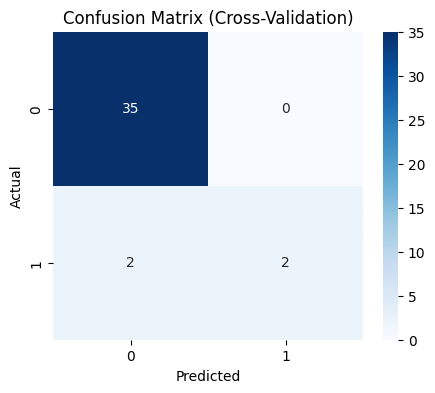

In [ ]:

from sklearn.model_selection import cross_val_predict
y_pred_cv = cross_val_predict(clf, X, y, cv=skf)
cm = confusion_matrix(y, y_pred_cv)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Cross-Validation)")
plt.show()


In [ ]:
!pip install pandas matplotlib seaborn scikit-learn --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.metrics import classification_report, confusion_matrix


In [ ]:
df_emotions = pd.read_csv('/content/face_emotions.csv')
emotion_cols = ['angry','disgust','fear','happy','sad','surprise','neutral']


In [ ]:
# User can change this value
frames_per_ball = 1  # try 5, 10, 25 depending on desired granularity
num_balls = len(df_emotions) // frames_per_ball
print(f"Generating dataset for {num_balls} balls.")


Generating dataset for 198 balls.


In [ ]:
ball_data = []

for i in range(num_balls):
    ball_frames = df_emotions.iloc[i*frames_per_ball : (i+1)*frames_per_ball]
    avg_emotions = ball_frames[emotion_cols].mean()
    dominant_emotion = avg_emotions.idxmax()
    performance_score = sum(avg_emotions[emo]*weights[emo] for emo in emotion_cols)
    perform_under_pressure = int(performance_score > 0)

    ball_data.append({
        'ball_number': i+1,
        **avg_emotions.to_dict(),
        'dominant_emotion': dominant_emotion,
        'performance_score': performance_score,
        'perform_under_pressure': perform_under_pressure
    })

df_ball = pd.DataFrame(ball_data)
df_ball.head()


,ball_number,angry,disgust,fear,happy,sad,surprise,neutral,dominant_emotion,performance_score,perform_under_pressure
0,1,0.58,0.01,0.21,0.03,0.13,0.01,0.04,angry,-0.85,0
1,2,0.63,0.00,0.11,0.13,0.11,0.00,0.02,angry,-0.70,0
2,3,0.00,0.00,0.00,1.00,0.00,0.00,0.00,happy,1.00,1
3,4,0.19,0.00,0.33,0.05,0.30,0.03,0.11,fear,-0.63,0
4,5,0.08,0.00,0.17,0.05,0.54,0.06,0.10,sad,-0.58,0


Cross-Validation Accuracy Scores: [1.         0.95       0.95       0.94871795 0.8974359 ]
Mean Accuracy: 0.9492307692307692
Standard Deviation: 0.03243969776054531


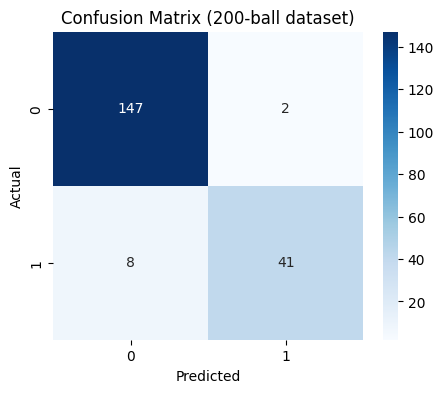


Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.99      0.97       149
           1       0.95      0.84      0.89        49

    accuracy                           0.95       198
   macro avg       0.95      0.91      0.93       198
weighted avg       0.95      0.95      0.95       198



In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

X = df_ball[emotion_cols]
y = df_ball['perform_under_pressure']

clf = RandomForestClassifier(n_estimators=100, random_state=42)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Cross-validation scores
scores = cross_val_score(clf, X, y, cv=skf, scoring='accuracy')
print("Cross-Validation Accuracy Scores:", scores)
print("Mean Accuracy:", scores.mean())
print("Standard Deviation:", scores.std())

# Confusion matrix
y_pred_cv = cross_val_predict(clf, X, y, cv=skf)
cm = confusion_matrix(y, y_pred_cv)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (200-ball dataset)")
plt.show()

# Classification report
print("\nClassification Report:\n", classification_report(y, y_pred_cv))


In [ ]:
england_players = [
    "Joe Root", "Zak Crawley", "Dom Sibley", "Ben Stokes",
    "Jonny Bairstow", "Ollie Pope", "Jos Buttler", "Chris Woakes",
    "Stuart Broad", "Jack Leach", "James Anderson"
]

australia_players = [
    "David Warner", "Marcus Harris", "Marnus Labuschagne", "Steve Smith",
    "Travis Head", "Cameron Green", "Alex Carey", "Pat Cummins",
    "Mitchell Starc", "Nathan Lyon", "Josh Hazlewood"
]

all_players = england_players + australia_players



In [ ]:
num_players = len(all_players)
df_ball['player'] = [all_players[i % num_players] for i in range(len(df_ball))]
balls_per_player_chunk = 10
df_ball['player'] = [all_players[(i // balls_per_player_chunk) % len(all_players)] for i in range(len(df_ball))]


Cross-Validation Accuracy Scores: [1.         0.95       0.95       0.94871795 0.8974359 ]
Mean Accuracy: 0.9492307692307692
Standard Deviation: 0.03243969776054531


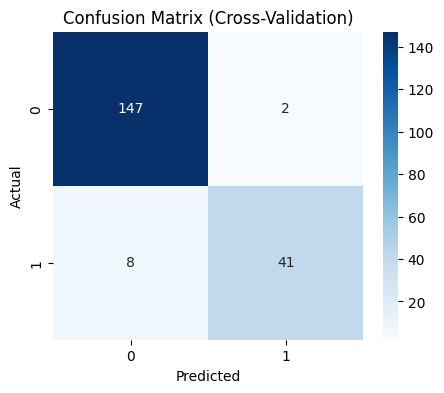


Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.99      0.97       149
           1       0.95      0.84      0.89        49

    accuracy                           0.95       198
   macro avg       0.95      0.91      0.93       198
weighted avg       0.95      0.95      0.95       198



In [ ]:
X = df_ball[emotion_cols]
y = df_ball['perform_under_pressure']

clf = RandomForestClassifier(n_estimators=100, random_state=42)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Accuracy per fold
scores = cross_val_score(clf, X, y, cv=skf, scoring='accuracy')
print("Cross-Validation Accuracy Scores:", scores)
print("Mean Accuracy:", scores.mean())
print("Standard Deviation:", scores.std())

# Confusion matrix
y_pred_cv = cross_val_predict(clf, X, y, cv=skf)
cm = confusion_matrix(y, y_pred_cv)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Cross-Validation)")
plt.show()

# Classification report
print("\nClassification Report:\n", classification_report(y, y_pred_cv))


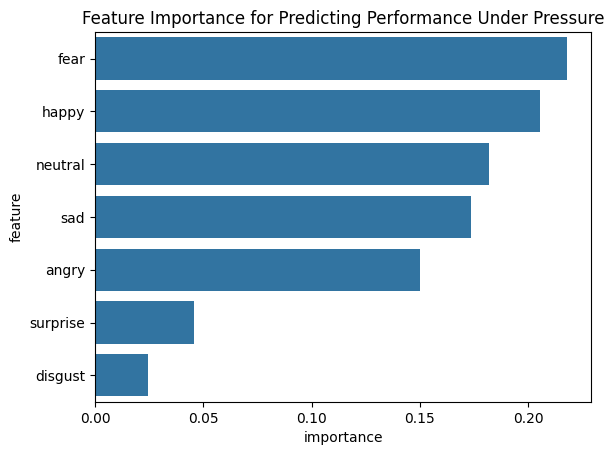

In [ ]:
clf.fit(X, y)
feat_importance = pd.DataFrame({
    'feature': emotion_cols,
    'importance': clf.feature_importances_
}).sort_values('importance', ascending=False)

sns.barplot(x='importance', y='feature', data=feat_importance)
plt.title("Feature Importance for Predicting Performance Under Pressure")
plt.show()


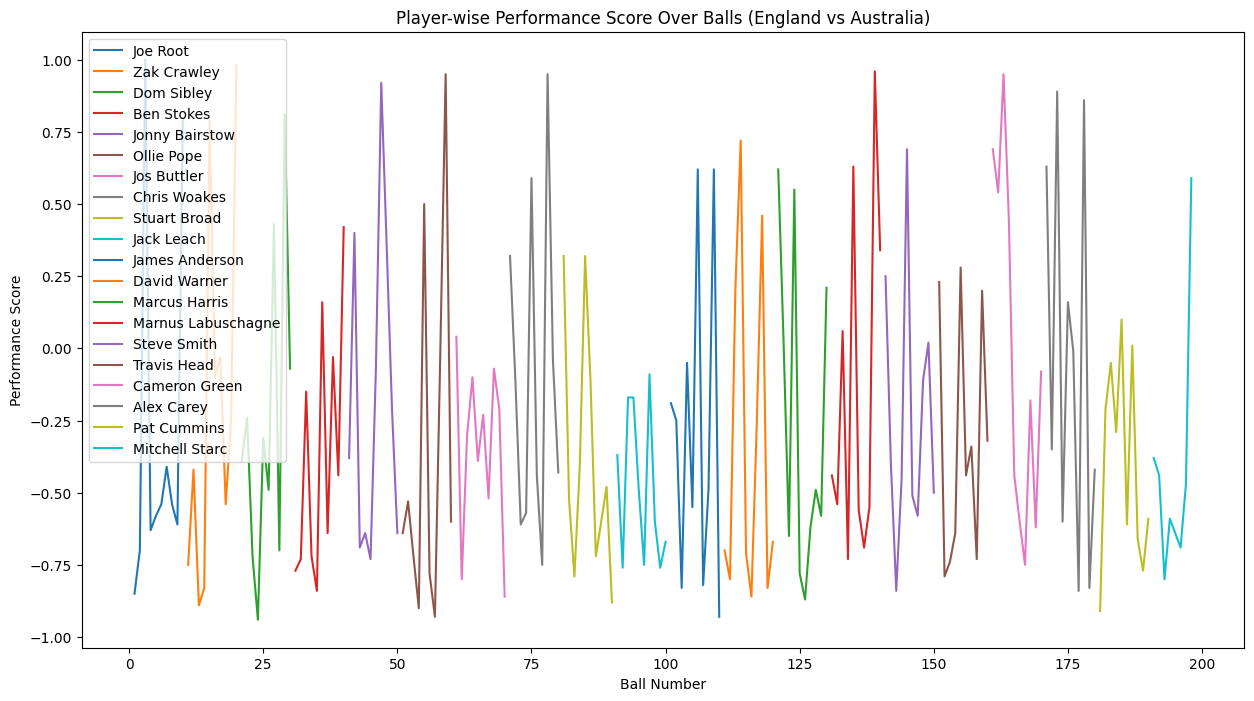

In [ ]:
plt.figure(figsize=(15,8))
for player in df_ball['player'].unique():
    player_data = df_ball[df_ball['player'] == player]
    sns.lineplot(x='ball_number', y='performance_score', data=player_data, label=player)
plt.title("Player-wise Performance Score Over Balls (England vs Australia)")
plt.xlabel("Ball Number")
plt.ylabel("Performance Score")
plt.legend()
plt.show()


  pivot_numeric = pivot_data.replace(emotion_map)



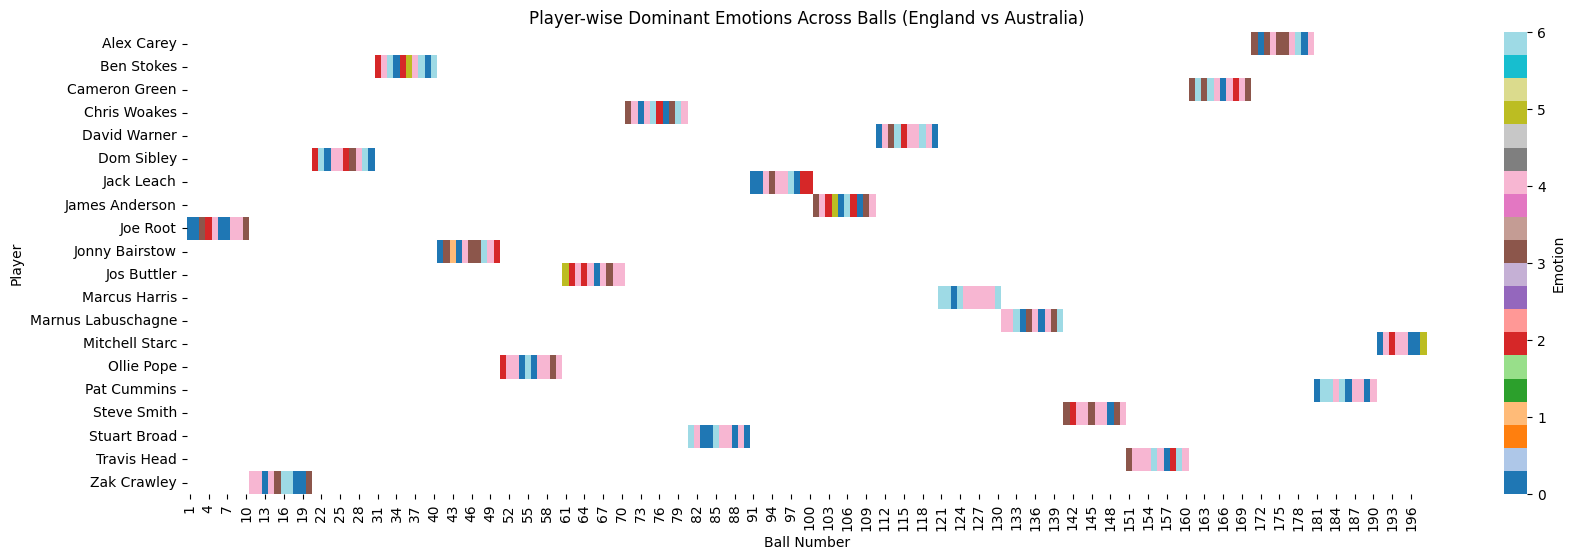

In [ ]:
pivot_data = df_ball.pivot(index='player', columns='ball_number', values='dominant_emotion')
emotion_map = {emo: i for i, emo in enumerate(emotion_cols)}
pivot_numeric = pivot_data.replace(emotion_map)

plt.figure(figsize=(20,6))
sns.heatmap(pivot_numeric, cmap='tab20', cbar_kws={'ticks': list(emotion_map.values()), 'label': 'Emotion'})
plt.title("Player-wise Dominant Emotions Across Balls (England vs Australia)")
plt.xlabel("Ball Number")
plt.ylabel("Player")
plt.show()


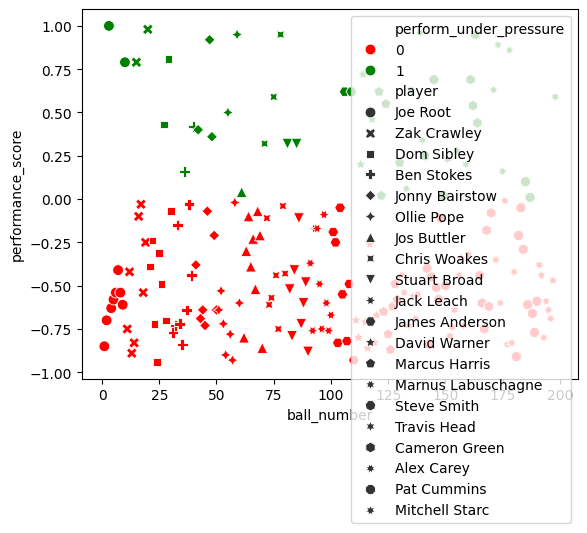

In [ ]:
sns.scatterplot(
    x='ball_number',
    y='performance_score',
    data=df_ball,
    hue='perform_under_pressure',
    style='player',  # each player gets a different marker
    palette={1:'green', 0:'red'},
    s=60
)
plt.show()


In [ ]:
# Example: train on some players, test on others
train_players = ['Joe Root', 'Ben Stokes', 'David Warner', 'Steve Smith']
test_players = [p for p in df_ball['player'].unique() if p not in train_players]

train_data = df_ball[df_ball['player'].isin(train_players)]
test_data = df_ball[df_ball['player'].isin(test_players)]

X_train = train_data[emotion_cols]
y_train = train_data['perform_under_pressure']

X_test = test_data[emotion_cols]
y_test = test_data['perform_under_pressure']

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)


In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


Test Accuracy: 0.9177215189873418
Confusion Matrix:
 [[116   3]
 [ 10  29]]
              precision    recall  f1-score   support

           0       0.92      0.97      0.95       119
           1       0.91      0.74      0.82        39

    accuracy                           0.92       158
   macro avg       0.91      0.86      0.88       158
weighted avg       0.92      0.92      0.91       158



In [ ]:
# Group by player and dominant emotion
player_emotion_stats = df_ball.groupby(['player', 'dominant_emotion']).agg(
    balls_count=('ball_number', 'count'),
    avg_performance=('performance_score', 'mean'),
    high_pressure_count=('perform_under_pressure', 'sum')
).reset_index()

# Calculate percentage of high-pressure balls
player_emotion_stats['high_pressure_pct'] = player_emotion_stats['high_pressure_count'] / player_emotion_stats['balls_count'] * 100

player_emotion_stats.head(20)


,player,dominant_emotion,balls_count,avg_performance,high_pressure_count,high_pressure_pct
0,Alex Carey,angry,2,-0.590000,0,0.000000
1,Alex Carey,happy,4,0.417500,3,75.000000
2,Alex Carey,neutral,1,0.860000,1,100.000000
3,Alex Carey,sad,3,-0.620000,0,0.000000
4,Ben Stokes,angry,2,-0.580000,0,0.000000
5,Ben Stokes,fear,2,-0.805000,0,0.000000
6,Ben Stokes,neutral,3,0.080000,1,33.333333
7,Ben Stokes,sad,2,-0.685000,0,0.000000
8,Ben Stokes,surprise,1,0.160000,1,100.000000
9,Cameron Green,angry,1,-0.600000,0,0.000000


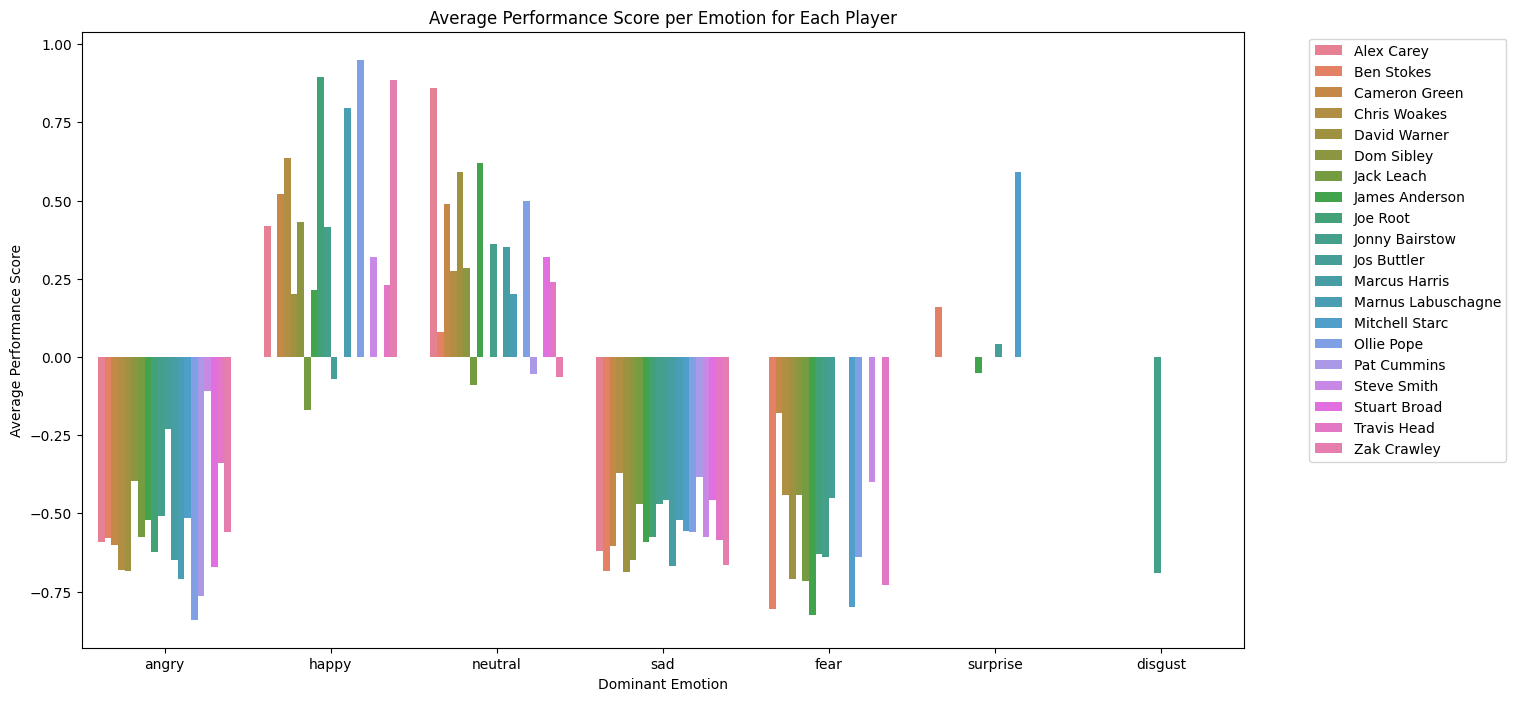

In [ ]:
plt.figure(figsize=(15,8))
sns.barplot(
    x='dominant_emotion',
    y='avg_performance',
    hue='player',
    data=player_emotion_stats
)
plt.title("Average Performance Score per Emotion for Each Player")
plt.xlabel("Dominant Emotion")
plt.ylabel("Average Performance Score")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


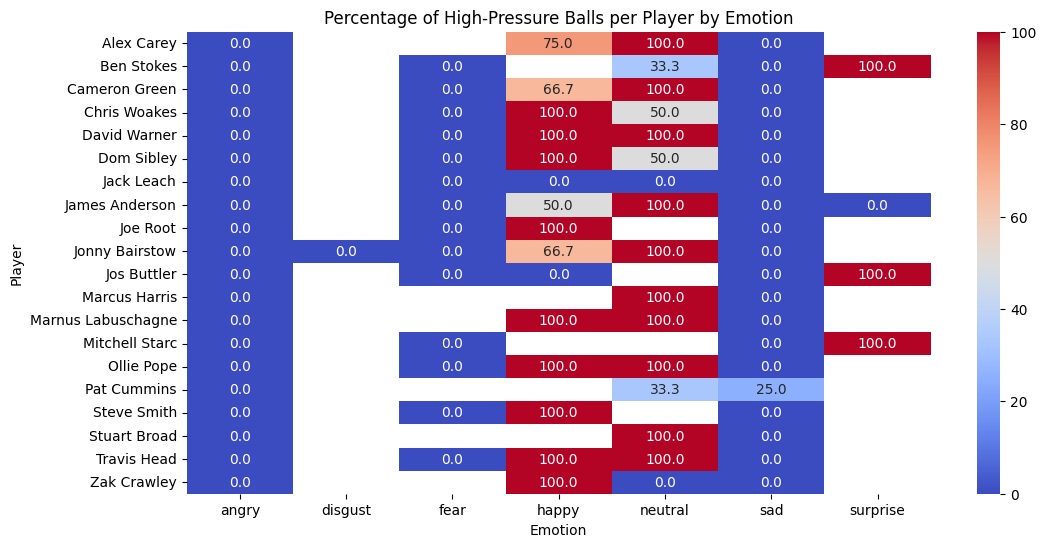

In [ ]:
heatmap_data = player_emotion_stats.pivot(index='player', columns='dominant_emotion', values='high_pressure_pct')

plt.figure(figsize=(12,6))
sns.heatmap(heatmap_data, annot=True, fmt=".1f", cmap="coolwarm")
plt.title("Percentage of High-Pressure Balls per Player by Emotion")
plt.xlabel("Emotion")
plt.ylabel("Player")
plt.show()


In [ ]:
# Example: top insights per player
for player in player_emotion_stats['player'].unique():
    data = player_emotion_stats[player_emotion_stats['player'] == player]
    best_emotion = data.loc[data['avg_performance'].idxmax()]['dominant_emotion']
    worst_emotion = data.loc[data['avg_performance'].idxmin()]['dominant_emotion']
    high_pressure_emotion = data.loc[data['high_pressure_pct'].idxmax()]['dominant_emotion']

    print(f"{player}:")
    print(f"  Performs best when: {best_emotion}")
    print(f"  Performs worst when: {worst_emotion}")
    print(f"  Most high-pressure balls under: {high_pressure_emotion}")
    print("-"*50)


Alex Carey:
  Performs best when: neutral
  Performs worst when: sad
  Most high-pressure balls under: neutral
--------------------------------------------------
Ben Stokes:
  Performs best when: surprise
  Performs worst when: fear
  Most high-pressure balls under: surprise
--------------------------------------------------
Cameron Green:
  Performs best when: happy
  Performs worst when: sad
  Most high-pressure balls under: neutral
--------------------------------------------------
Chris Woakes:
  Performs best when: happy
  Performs worst when: angry
  Most high-pressure balls under: happy
--------------------------------------------------
David Warner:
  Performs best when: neutral
  Performs worst when: fear
  Most high-pressure balls under: happy
--------------------------------------------------
Dom Sibley:
  Performs best when: happy
  Performs worst when: sad
  Most high-pressure balls under: happy
--------------------------------------------------
Jack Leach:
  Performs best

In [ ]:
df_ball = df_ball.sort_values(['player', 'ball_number'])

# Create lag features for previous 1-3 balls
lag_features = emotion_cols
for lag in range(1, 4):
    for f in lag_features:
        df_ball[f'{f}_lag{lag}'] = df_ball.groupby('player')[f].shift(lag)

df_future_perf = df_ball.dropna()

X = df_future_perf[[f'{f}_lag{l}' for l in range(1,4) for f in lag_features]]
y = df_future_perf['perform_under_pressure']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print("Future Performance Prediction Accuracy:", (y_pred==y_test).mean())


Future Performance Prediction Accuracy: 0.75


Clutch Player Scores (High Pressure Performance %):
 player
Alex Carey            0.400
Marnus Labuschagne    0.400
Cameron Green         0.400
Marcus Harris         0.400
Chris Woakes          0.300
David Warner          0.300
Travis Head           0.300
Steve Smith           0.300
Jonny Bairstow        0.300
Stuart Broad          0.200
Pat Cummins           0.200
Ollie Pope            0.200
Zak Crawley           0.200
Ben Stokes            0.200
Joe Root              0.200
James Anderson        0.200
Dom Sibley            0.200
Mitchell Starc        0.125
Jos Buttler           0.100
Jack Leach            0.000
Name: perform_under_pressure, dtype: float64


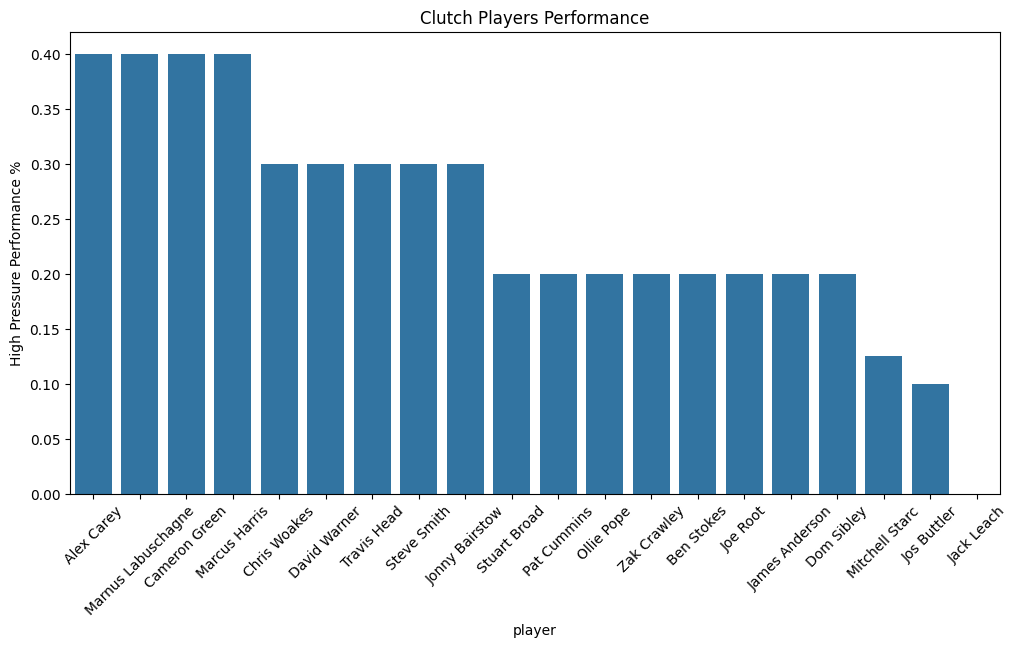

In [ ]:
clutch_scores = df_ball.groupby('player')['perform_under_pressure'].mean().sort_values(ascending=False)
print("Clutch Player Scores (High Pressure Performance %):\n", clutch_scores)

# Visualization
plt.figure(figsize=(12,6))
sns.barplot(x=clutch_scores.index, y=clutch_scores.values)
plt.xticks(rotation=45)
plt.ylabel("High Pressure Performance %")
plt.title("Clutch Players Performance")
plt.show()


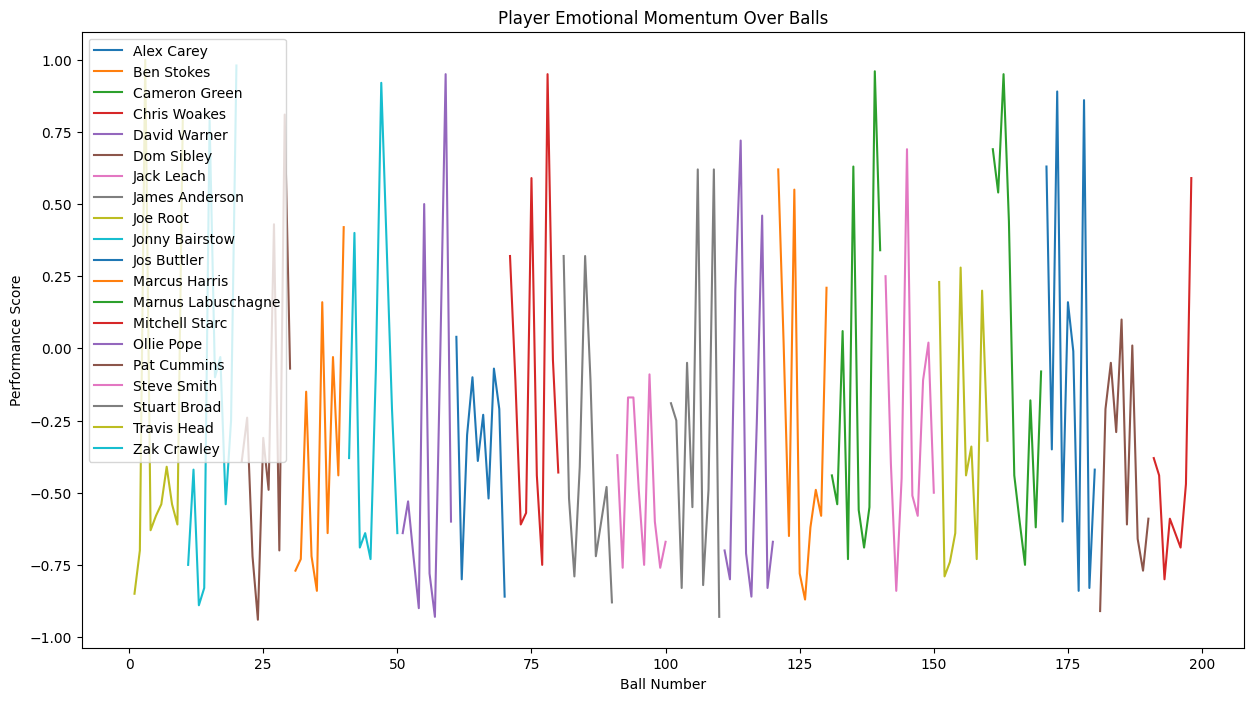

In [ ]:
plt.figure(figsize=(15,8))
for player in df_ball['player'].unique():
    player_data = df_ball[df_ball['player']==player]
    sns.lineplot(x='ball_number', y='performance_score', data=player_data, label=player)
plt.title("Player Emotional Momentum Over Balls")
plt.xlabel("Ball Number")
plt.ylabel("Performance Score")
plt.legend()
plt.show()


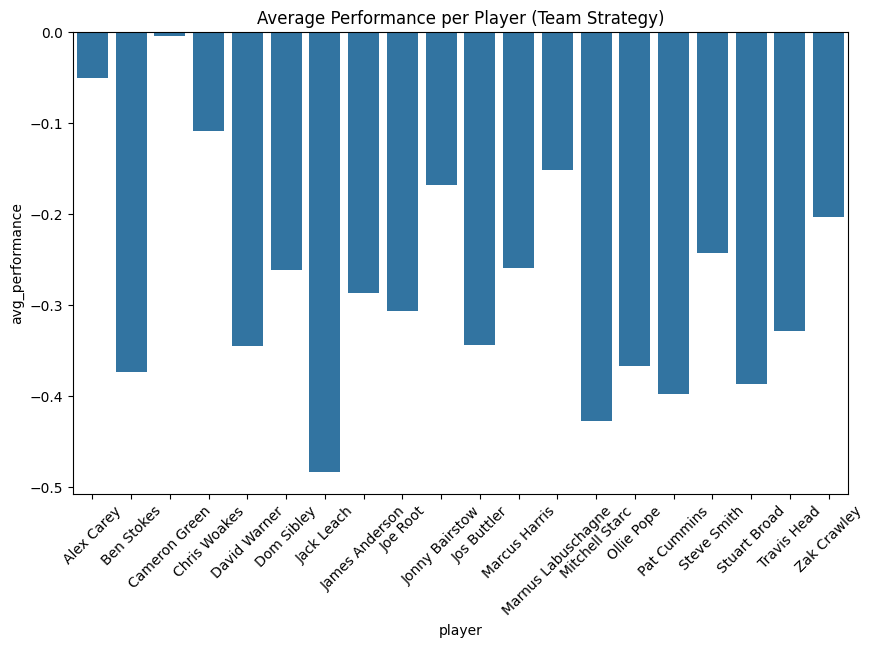

In [ ]:
team_stats = df_ball.groupby('player').agg(
    avg_performance=('performance_score','mean'),
    avg_pressure=('perform_under_pressure','mean')
).reset_index()

plt.figure(figsize=(10,6))
sns.barplot(x='player', y='avg_performance', data=team_stats)
plt.xticks(rotation=45)
plt.title("Average Performance per Player (Team Strategy)")
plt.show()


In [ ]:
alert_threshold = 0  # performance_score <= 0 means stressed
df_ball['stress_alert'] = df_ball['performance_score'] <= alert_threshold

alerts = df_ball[df_ball['stress_alert']]
print("Real-Time Alerts (stressed balls):")
print(alerts[['ball_number','player','dominant_emotion','performance_score']])


Real-Time Alerts (stressed balls):
     ball_number       player dominant_emotion  performance_score
171          172   Alex Carey            angry              -0.35
173          174   Alex Carey              sad              -0.60
175          176   Alex Carey            happy              -0.01
176          177   Alex Carey              sad              -0.84
178          179   Alex Carey            angry              -0.83
..           ...          ...              ...                ...
13            14  Zak Crawley              sad              -0.83
15            16  Zak Crawley          neutral              -0.10
16            17  Zak Crawley          neutral              -0.03
17            18  Zak Crawley            angry              -0.54
18            19  Zak Crawley            angry              -0.25

[149 rows x 4 columns]


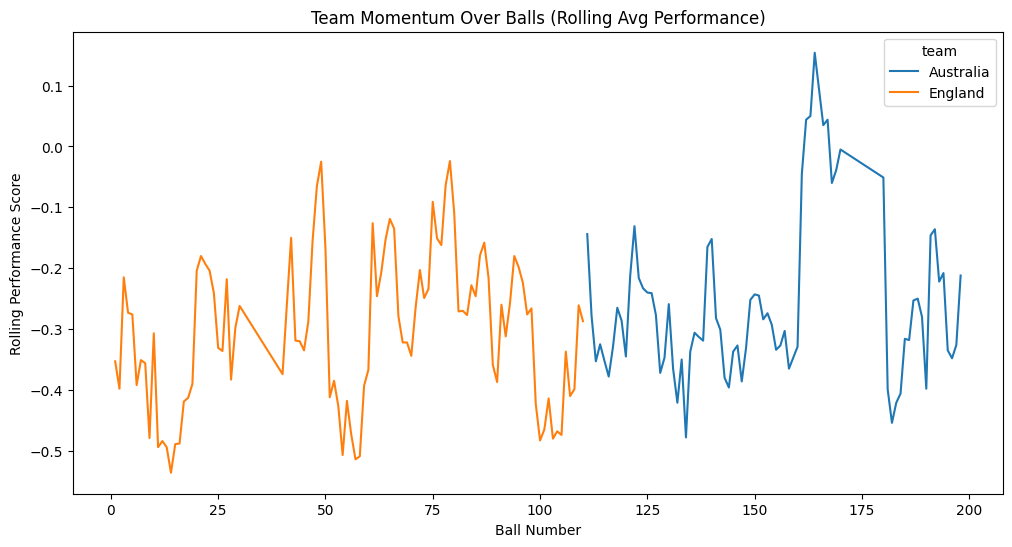

In [ ]:
# Aggregate team performance scores over a rolling window (e.g., 10 balls)
df_ball['team'] = df_ball['player'].apply(lambda x: 'England' if x in england_players else 'Australia')
team_momentum = df_ball.groupby('team').rolling(10, on='ball_number')['performance_score'].mean().reset_index()

plt.figure(figsize=(12,6))
sns.lineplot(x='ball_number', y='performance_score', hue='team', data=team_momentum)
plt.title("Team Momentum Over Balls (Rolling Avg Performance)")
plt.xlabel("Ball Number")
plt.ylabel("Rolling Performance Score")
plt.show()


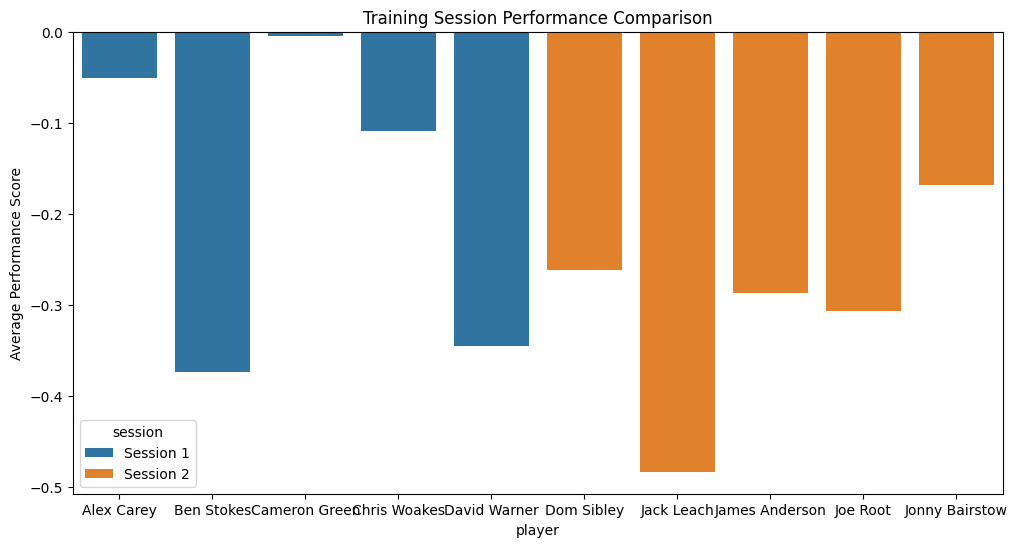

In [ ]:
# Simulate two sessions (first 50 balls vs last 50 balls)
session_labels = ['Session 1']*50 + ['Session 2']*50
df_session = df_ball.iloc[:100].copy()
df_session['session'] = session_labels

session_perf = df_session.groupby(['player','session'])['performance_score'].mean().reset_index()

plt.figure(figsize=(12,6))
sns.barplot(x='player', y='performance_score', hue='session', data=session_perf)
plt.title("Training Session Performance Comparison")
plt.ylabel("Average Performance Score")
plt.show()


Top Performances under Pressure:
     ball_number         player dominant_emotion  performance_score
170          171     Alex Carey            happy               0.63
172          173     Alex Carey            happy               0.89
177          178     Alex Carey          neutral               0.86
160          161  Cameron Green            happy               0.69
161          162  Cameron Green          neutral               0.54
162          163  Cameron Green            happy               0.95
74            75   Chris Woakes          neutral               0.59
77            78   Chris Woakes            happy               0.95
113          114   David Warner          neutral               0.72
28            29     Dom Sibley          neutral               0.81


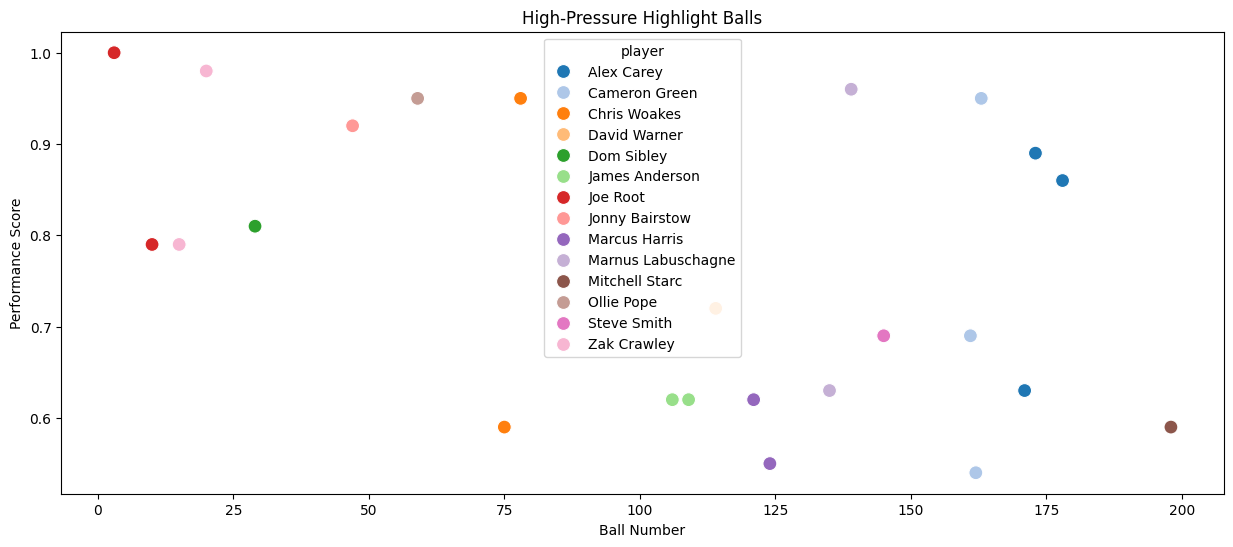

In [ ]:
# Select high-pressure success moments (performance_score > threshold)
threshold = 0.5
highlight_balls = df_ball[df_ball['performance_score'] > threshold]

print("Top Performances under Pressure:")
print(highlight_balls[['ball_number','player','dominant_emotion','performance_score']].head(10))

# Optional visualization: scatter plot of highlights
plt.figure(figsize=(15,6))
sns.scatterplot(x='ball_number', y='performance_score', hue='player', data=highlight_balls, s=100, palette='tab20')
plt.title("High-Pressure Highlight Balls")
plt.xlabel("Ball Number")
plt.ylabel("Performance Score")
plt.show()
